# PROVA 2 (PRÁTICA) PARADIGMAS DE APRENDIZAGEM DE MÁQUINA

## Nome: Francisco Santana de Sousa Júnior
## Matrícula: 20210025969

### 0. Instalando e importanto bibliotecas necessárias

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: C:\Users\franc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [8]:
pip install scikit-learn

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------  11.0/11.1 MB 68.5 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 53.2 MB/s eta 0:00:00
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
   ---------------------------------------- 0.0/40.9 MB ? eta -:--:--
   -------------- ------------------------- 14.4/40.9 MB 69.4 MB/s eta 0:00:01
   -------------------------- ------------- 27.3/40.9 MB 66.3 MB/s eta 0:00:01
   ------------------------------------- -- 38.0/40.9 MB 61.9 MB/s eta 0:00:01
   ---------------------------------------- 40.9/40.9 MB 50.0 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: C:\Users\franc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [7]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: C:\Users\franc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [9]:
pip install numpy 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: C:\Users\franc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [10]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: C:\Users\franc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFECV 
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


### 1. Pré-processamento de dados

In [55]:
df = pd.read_csv( 'radiomic_data_binary.csv' )
df.shape

(2018, 116)

In [56]:
df.head()

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,class
0,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}",{'Original': {}},245a9a4dd4a20aabe9c478e95a35aa833ca20590,2D,"(1.0, 1.0)",...,0.000038,8.692009,0.962976,0.040777,0.028123,0.000123,8.843847e+06,5.416673,42.367873,BENIGN
1,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}",{'Original': {}},b3a0776528a8f7438a2f6cc95486cafad01adefa,2D,"(1.0, 1.0)",...,0.000021,10.126931,0.963992,0.039417,0.002454,0.000299,4.859019e+07,14.347313,540.091956,BENIGN
2,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}",{'Original': {}},f204a9caa1dea0bd0cfa97a68b8b1b98e9c45054,2D,"(1.0, 1.0)",...,0.000023,9.818248,0.882666,0.167003,0.001089,0.000951,3.526641e+06,0.706177,687.525538,BENIGN
3,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}",{'Original': {}},8e7a5be028d372a7e1729e2bd28bac01c4a00a8b,2D,"(1.0, 1.0)",...,0.000021,9.865219,0.934424,0.078779,0.001812,0.000794,5.654092e+06,1.171521,381.671430,BENIGN
4,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}",{'Original': {}},1e4e7e585f4bfb62c816c1b42c5215a913246ea6,2D,"(1.0, 1.0)",...,0.000013,9.779599,0.926990,0.088650,0.003791,0.000372,5.173518e+06,1.087884,213.296874,BENIGN


In [57]:
df.describe()

,diagnostics_Image-original_Mean,diagnostics_Image-original_Minimum,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
count,2018.000000,2018.0,2018.0,2018.000000,2018.000000,2018.000000,2018.000000,2.018000e+03,2018.000000,2018.000000,...,2.018000e+03,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2.018000e+03,2018.000000,2018.000000
mean,18907.039002,0.0,65535.0,105036.668484,1.002973,39178.960753,55451.825273,2.456024e+14,9.334995,9019.392839,...,6.470894e+05,0.000053,9.691230,0.935455,69.326823,0.007869,0.000477,1.176247e+07,2.435959,418.211110
std,9753.197636,0.0,0.0,52763.326064,0.083260,11375.360008,5974.882393,1.367900e+14,0.620229,5503.557929,...,6.712049e+05,0.000170,0.609529,0.028786,871.935987,0.009592,0.000379,1.172687e+07,3.505917,596.869970
min,1348.495708,0.0,65535.0,7081.000000,1.000000,0.000000,22724.000000,1.049319e+13,7.071295,1087.000000,...,1.607526e+04,0.000002,7.524619,0.608132,0.035209,0.000163,0.000014,1.094131e+05,0.164897,6.686597
25%,11078.839099,0.0,65535.0,63441.250000,1.000000,34961.875000,52821.250000,1.398271e+14,8.922444,5486.000000,...,2.242887e+05,0.000013,9.297123,0.925089,0.052816,0.002116,0.000252,4.076563e+06,1.027537,109.643526
50%,17667.541729,0.0,65535.0,96599.000000,1.000000,41545.000000,56917.500000,2.231246e+14,9.352599,7723.500000,...,3.872933e+05,0.000019,9.715402,0.943314,0.066737,0.004630,0.000371,7.463225e+06,1.631355,209.194583
75%,25244.895199,0.0,65535.0,139960.500000,1.000000,46825.750000,59596.250000,3.279876e+14,9.751093,10832.250000,...,7.779073e+05,0.000030,10.110668,0.953438,0.094123,0.010167,0.000574,1.430029e+07,2.758621,451.778542
max,50919.143497,0.0,65535.0,255021.000000,4.000000,61932.000000,65535.000000,7.517255e+14,10.877354,43401.000000,...,4.558974e+06,0.002423,11.390202,0.967932,25359.248818,0.105756,0.003718,6.624754e+07,75.988470,6083.317415


Contando as diferentes classes

In [58]:
df['class'].value_counts()

class
BENIGN       1100
MALIGNANT     918
Name: count, dtype: int64

### 1.1 Verificando valores ausentes

In [59]:
missing_values = df.isnull().sum()
missing_values

diagnostics_Versions_PyRadiomics    0
diagnostics_Versions_Numpy          0
diagnostics_Versions_SimpleITK      0
diagnostics_Versions_PyWavelet      0
diagnostics_Versions_Python         0
                                   ..
original_ngtdm_Coarseness           0
original_ngtdm_Complexity           0
original_ngtdm_Contrast             0
original_ngtdm_Strength             0
class                               0
Length: 116, dtype: int64

In [60]:
missing_values[missing_values > 0]

Series([], dtype: int64)

A análise inicial da base de dados mostrou que não há valores ausentes em nenhuma das 116 features radiômicas. Isso é um indicativo de que a base foi bem processada previamente, o que permite pularmos a etapa de imputação de valores
e seguirmos diretamente para a análise de dimensionalidade. Caso existissem valores faltantes, poderíamos optar por imputação via média, mediana, ou técnicas baseadas em modelos. Agora podemos seguir para o próximo passo.

### 1.2 Redução da dimensionalidade

Verifica-se que há propriedades nesse dataset que correspondem a valores de versões de bibliotecas e outros valores que
não necessariamente importam para o nosso modelo, então faz sentido remover. Percebe-se que esses valores começam com o prefixo "diagnostics_".
Então vamos dropar as colunas que começam com esses valores. 

In [13]:
#Removendo colunas que possuem "diagnostics_" no inicio, pois são valores que não interessam para o modelo
columns_to_drop = [col for col in df.columns if col.startswith('diagnostics_')]
# Criando variavel X que corresponde ao df original dropado de colunas class, o rotulo que queremos descobrir
# e y é a variavel dos rótulos
X = df.drop(columns=columns_to_drop+['class'])
y = df['class']

### 1.3 Aplicando PCA para redução de dimensionalidade 
A técnica PCA foi aplicada após a padronização dos dados. Essa abordagem busca capturar as direções principais dos dados, reduzindo o número de atributos de 116 para um subconjunto mais compacto, o que pode reduzir overfitting e acelerar o treinamento.


In [61]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 

#definição do scaler
#Aqui os dados em X são padronizados, isso é importante pois o PCA
# é sensível a escala de variáveis
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

#Aqui definimos n_components como 95 pois queremos que o
# PCA escolha automaticamente o menor número de componentes principais
# que mantém 95% da variância explicada dos dados originais 
# Aqui também fixamos o random state para 42 para garantir reprodutibilidade dos resultados
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Número de componentes antes do PCA: {X_scaled.shape[1]}")
print(f"Número de componentes após PCA: {X_pca.shape[1]}")

Número de componentes antes do PCA: 93
Número de componentes após PCA: 11


Agora que temos:
    X_scaled (dados normalizados sem redução),
    X_pca (dados normalizados e com redução via PCA),
    y (rótulos)

### 1.4 Redução de dimensionalidade via seleção de atributos

### 1.4.1 Seleção baseada em importância dos atributos 

Aqui, vamos usar a importância dos atributos de uma RandomForest para fazer a redução da 
dimensionalidade 

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel 

#Modelo para calcular importancia 
model = RandomForestClassifier(random_state=42)
model.fit(X_scaled, y)

#Seleciona as features mais importantes
selector = SelectFromModel(model, prefit=True)
X_selected_importance = selector.transform(X_scaled)

#Comparação entre as features anteriores e atuais
print(f'Número de features antes da seleção: {X_scaled.shape[1]}')
print(f'Número de features depois da seleção: {X_selected_importance.shape[1]}')

Número de features antes da seleção: 93
Número de features depois da seleção: 46


### 1.4.2 Aplicando RFE(Recursive Feature Elimination)

 Aqui vamos treinar o modelo e eliminando as features iterativamente. RFE Vai retirando 
 os atributos aos poucos e testando até ficar só com os mais relevantes

In [63]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=model, n_features_to_select=30)
X_selected_rfe = rfe.fit_transform(X_scaled, y)

print(f"Número de features antes da seleção: {X_scaled.shape[1]}")
print(f"Número de features depois da seleção: {X_selected_rfe.shape[1]}")

Número de features antes da seleção: 93
Número de features depois da seleção: 30


A seleção por importância (via Random Forest) e o RFE priorizam atributos com maior impacto direto na
acurácia preditiva dos modelos, oferecendo uma redução guiada por desempenho real.

Ao utilizar essas técnicas em conjunto, conseguimos avaliar não apenas a compactação dos dados, mas
também seu impacto na performance dos modelos preditivos.

Agora que aplicamos 3 formas diferentes de redução de dimensionalidade, é necessario 
avaliar o impacto dessas reduções

### 1.5 Avaliando o Impacto

Para avaliar o impacto primeiro precisamos:
- Treinar um modelo baseline (sem redução de dimensionalidade) com X completo 
- Treinar o mesmo modelo usando: X reduzido pelo PCA, X reduzido pela importancia dos modelos, x reduzido pelo RFE.
- Comparar as métricas usando validação cruzada estratificada 10-fold

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Criando modelo usando random forest
model = RandomForestClassifier(random_state=42)
#Definindo validação cruzada estratificada 
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
#1. Baseline: sem redução 
scores_full = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
#2. Com PCA
scores_pca = cross_val_score(model, X_pca, y, cv=cv, scoring="accuracy")
#3. Com Seleção de atributos por importância do modelo
scores_importance = cross_val_score(model, X_selected_importance, y, cv=cv, scoring="accuracy")
#4. Com RFE 
scores_rfe = cross_val_score(model, X_selected_rfe, y, cv=cv, scoring='accuracy')

print("Baseline (sem redução) - Acurácia média:", np.mean(scores_full))
print("PCA - Acurácia média:", np.mean(scores_pca))
print("Seleção por importância - Acurácia média:", np.mean(scores_importance))
print("RFE - Acurácia média:", np.mean(scores_rfe))

Baseline (sem redução) - Acurácia média: 0.6065686419388208
PCA - Acurácia média: 0.6224299295601202
Seleção por importância - Acurácia média: 0.6115117481897443
RFE - Acurácia média: 0.6273754987439043


Analisando:
Baseline (sem redução) teve 60,6% de acurácia.
- Serve como referência para saber se reduzir as dimensões ajuda ou atrapalha.

PCA subiu a acurácia para 62,2%.
- Melhorou um pouco! PCA consegue captar boa parte da variação dos dados em menos dimensões.

Seleção de atributos por importância ficou em 61,1%.
- Também melhorou em relação ao baseline, mas menos que PCA.

RFE deu o melhor resultado: 62,7%.
-  Mostrou que, além de reduzir dimensionalidade, eliminou variáveis irrelevantes, deixando o modelo ainda mais focado no que importa.

Com isso podemos ter a conclusão de que a redução de dimensionalidade teve um impacto positivo nos modelos.
Tanto o PCA quanto a seleção de atributos aumentaram a acurácia média em comparação com a base original, no entanto
A técnica de RFE apresentou o melhor desempenho, indicando que uma seleção cuidadosa de atributos pode melhorar a generalização do modelo.

### 1.6 Treinamento e comparação do desempenho dos modelos

Agora que conseguimos determinar qual é a melhor forma de fazer a redução de dimensionalidade usando random-forest , precisamos agora treinar dois novos modelos: Árvore de decisão e MLP(perceptron multicamadas) e verificar as diferentes técnicas de redimensionalidade. 

Utilizamos a métrica f1_macro por tratar igualmente as duas classes (BENIGN e MALIGNANT
independentemente do seu tamanho no dataset. Como a acurácia pode ser enganosa em cenários 
desbalanceados, o F1-score macro oferece uma medida mais justa e sensível ao desempenho real do modelo 
em cada classe — o que é especialmente importante no contexto médico, onde falsos negativos podem ter 
consequências graves.

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier 

#criando os modelos
dt_model = DecisionTreeClassifier(random_state=42)
mlp_model=MLPClassifier(random_state=42, max_iter=1000)

#Usando a mesma validação cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#TREINANDO E AVALIANDO
#1. Árvore de decisão baseline
scores_dt_full = cross_val_score(dt_model, X_scaled, y, cv=cv, scoring="f1_macro")
#2. MLP baseline
scores_mlp_full = cross_val_score(mlp_model, X_scaled, y, cv=cv, scoring='f1_macro')
#3. Árvore de decisão com PCA
scores_dt_pca = cross_val_score(dt_model, X_pca, y, cv=cv, scoring='f1_macro')
#4. MLP com PCA
scores_mlp_pca = cross_val_score(mlp_model,X_pca, y, cv=cv, scoring='f1_macro')
#5. Arvores de decisão com seleção por importancia 
scores_dt_importance = cross_val_score(dt_model, X_selected_importance, y, cv=cv, scoring='f1_macro')
#6. MLP - Com seleção por importância
scores_mlp_importance = cross_val_score(mlp_model, X_selected_importance, y, cv=cv, scoring='f1_macro')

#7. Arvores de decisão com RFE
scores_dt_rfe = cross_val_score(dt_model, X_selected_rfe, y, cv=cv, scoring='f1_macro')
#8.MLP com rfe
scores_mlp_rfe = cross_val_score(mlp_model, X_selected_rfe, y,  cv=cv, scoring='f1_macro')



In [65]:
results = {
    "Modelo": ["Decision Tree", "Decision Tree", "Decision Tree", "Decision Tree",
               "MLP", "MLP", "MLP", "MLP"],
    "Versão dos dados": ["X_scaled", "X_pca", "X_selected_importance", "X_selected_rfe"]*2,
    "F1-Score médio": [
        scores_dt_full.mean(), scores_dt_pca.mean(), scores_dt_importance.mean(), scores_dt_rfe.mean(),
        scores_mlp_full.mean(), scores_mlp_pca.mean(), scores_mlp_importance.mean(), scores_mlp_rfe.mean()
    ],
    "Desvio Padrão": [
        scores_dt_full.std(), scores_dt_pca.std(), scores_dt_importance.std(), scores_dt_rfe.std(),
        scores_mlp_full.std(), scores_mlp_pca.std(), scores_mlp_importance.std(), scores_mlp_rfe.std()
    ]
}

df_results = pd.DataFrame(results)
display(df_results)

,Modelo,Versão dos dados,F1-Score médio,Desvio Padrão
0,Decision Tree,X_scaled,0.553376,0.036214
1,Decision Tree,X_pca,0.554804,0.031174
2,Decision Tree,X_selected_importance,0.559946,0.028792
3,Decision Tree,X_selected_rfe,0.560345,0.029115
4,MLP,X_scaled,0.624509,0.035849
5,MLP,X_pca,0.612803,0.028299
6,MLP,X_selected_importance,0.642272,0.032964
7,MLP,X_selected_rfe,0.623546,0.036180


Com base nos resultados obtidos para o F1-score médio com validação cruzada estratificada, avaliamos o impacto das técnicas de redução de dimensionalidade sobre o desempenho dos modelos de Árvore de Decisão e MLP.

Árvore de decisão: 
Para o X_scaled tem F1 score médio de 0.553 e desvio padrão de 0.036. 

Para o X_PCA tem f1 score médio de 0.554 e desvio padrão de 0.311.

Para o X_selected_importance temos 0.559 e desvio padrão de 0.028

Para o X_selected_rfe temos f1 score médio de 0.560 e desvio padrão de 0.029

A Árvore de Decisão apresentou um leve ganho de desempenho com todas as técnicas de redução de 
dimensionalidade. A melhora mais consistente foi com seleção por importância e RFE, ambas alcançando o 
melhor F1-score médio. A aplicação de PCA teve um impacto marginalmente positivo, indicando que a 
redução com base na variância explicada capturou algumas características úteis, mas não foi tão eficaz 
quanto métodos baseados em importância preditiva. Assim, RFE ou seleção por importância são as 
abordagens mais recomendadas para este modelo.


MLP:
Para o X_scaled temos 0.624 de f1-score médio e 0.035 para o desvio padrão

Para o X_pca temos 0.612 para o f1-score médio e 0.028 de desvio padrão

Para o X_selected_importance temos 0.62 de f1-score médio e 0.032 para o desvio padrão

Para o X_selected_rfe temos 0.62 para o f1-score-médio e 0.036 para o desvio padrão. 

O MLP obteve desempenho superior à Árvore de Decisão em todos os cenários. A maior melhoria ocorreu com 
seleção por importância, atingindo o melhor F1-score geral (0.642 ± 0.033). A aplicação de PCA resultou 
em queda de desempenho, sugerindo que a compressão dos dados pode ter eliminado características 
importantes. O uso de RFE apresentou desempenho similar ao baseline.

Portanto, para o MLP, a seleção por importância se destaca como a estratégia mais eficaz, enquanto PCA 
deve ser evitada, dado o impacto negativo na capacidade preditiva do modelo.

### 1.3 Avaliando os modelos utilizando F1-Score, matriz de confusão e curva ROC/AUC

In [66]:
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
import seaborn as sns 



In [67]:
# Função para calcular e definir a matriz de confusão 
def plot_confusion_matrix(cm, class_names): 
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Matriz de confusão")
    plt.ylabel("Classe verdadeira")
    plt.xlabel("Classe Predita")
    plt.show()



Primeiro precisamos transformar os valores que estão no Y em valores numericos assim BENIGN fica 0 e
MALIGNANT fica 1

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_numeric = le.fit_transform(y)
y_numeric

array([0, 0, 0, ..., 1, 1, 1], shape=(2018,))

Este trecho utiliza validação cruzada com cross_val_predict para obter as probabilidades de cada amostra 
pertencente à classe positiva (MALIGNANT) nos modelos de Árvore de Decisão e MLP, converte essas 
probabilidades em rótulos binários com .round(), calcula o F1-score ponderado (f1_weighted) para avaliar 
o desempenho considerando o desbalanceamento entre classes e, por fim, gera a matriz de confusão para 
cada modelo, permitindo a análise dos acertos e erros em termos de verdadeiros e falsos positivos e 
negativos.

In [69]:
# Previsões para avaliação usando cross_val_predict
# para obter probabilidades necessárias à curva ROC
y_pred_dt = cross_val_predict(dt_model, X_scaled, y_numeric, cv=cv, method='predict_proba')[:, 1]
y_pred_mlp = cross_val_predict(mlp_model, X_scaled, y_numeric, cv=cv, method='predict_proba')[:, 1]

# Cálculo do F1-Score
f1_dt = f1_score(y_numeric, y_pred_dt.round(), average='weighted')  # .round() para obter a classe predita 
# Definimos o average='weighted' pois precisamos garantir que o desempenho do modelo
# seja avaliado de forma justa em datasets desbalanceados
f1_mlp = f1_score(y_numeric, y_pred_mlp.round(), average='weighted')

# Cálculo da matriz de confusão
y_pred_dt_class = y_pred_dt.round()  # Convertendo as probabilidades para classes (0 ou 1)
y_pred_mlp_class = y_pred_mlp.round()  # Convertendo as probabilidades para classes (0 ou 1)

cm_dt = confusion_matrix(y_numeric, y_pred_dt_class)
cm_mlp = confusion_matrix(y_numeric, y_pred_mlp_class)


=== Matriz de Confusão - Árvore de Decisão ===


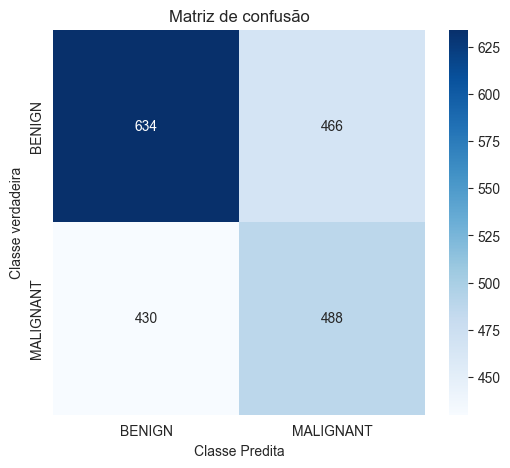

In [70]:
print("\n=== Matriz de Confusão - Árvore de Decisão ===")
plot_confusion_matrix(cm_dt, class_names=['BENIGN', 'MALIGNANT'])

Essa matriz de confusão da Árvore de Decisão mostra:

634 casos de BENIGN que foram corretamente classificados como BENIGN (verdadeiros negativos).
466 casos de BENIGN que foram classificados incorretamente como MALIGNANT (falsos positivos).
430 casos de MALIGNANT classificados como BENIGN (falsos negativos).
488 casos de MALIGNANT corretamente classificados como MALIGNANT (verdadeiros positivos).

O modelo parece ter dificuldades tanto em identificar corretamente os malignos quanto em não confundir benignos como malignos.


=== Matriz de Confusão - MLP ===


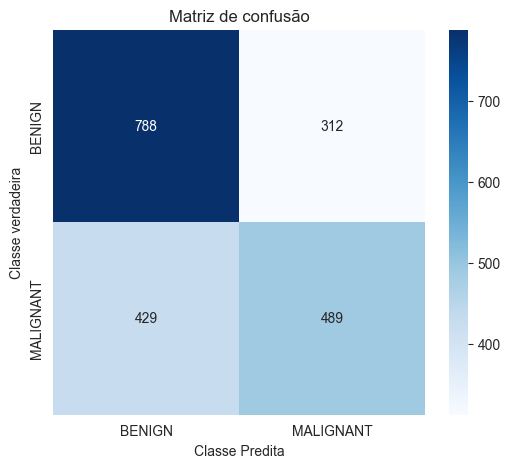

In [71]:
print("\n=== Matriz de Confusão - MLP ===")
plot_confusion_matrix(cm_mlp, class_names=['BENIGN', 'MALIGNANT'])


788 casos de BENIGN corretamente classificados como BENIGN.
312 casos de BENIGN incorretamente classificados como MALIGNANT.
429 casos de MALIGNANT classificados como BENIGN.
489 casos de MALIGNANT corretamente classificados como MALIGNANT.

Aqui percebemos que o MLP apresentou melhor desempenho quando comparado à arvore de decisão pois tem uma menor taxa de falsos positivos e verdadeiros negativos.

In [72]:
# Função para calcular e exibir a curva ROC
def plot_roc_curve(fpr, tpr, auc_score):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()

Aqui vamos calcular e preparar os dados para a curva ROC  e o valor da de AUC(Área sob a curva ROC) para os modelos de árvore de 
decisão e MLP

In [73]:
#As linhas abaixo calculam os valores de taxa de falsos positivos (FPR) 
#e taxa de verdadeiros positivos (TPR) para diferentes thresholds

fpr_dt, tpr_dt, _ = roc_curve(y_numeric, y_pred_dt)
fpr_mlp, tpr_mlp, _ = roc_curve(y_numeric, y_pred_mlp)

#Calculo da area sob a curva roc
# Medindo a capádidade do modelo de distinguir entre as classes 
auc_dt = auc(fpr_dt, tpr_dt)
auc_mlp = auc(fpr_mlp, tpr_mlp)

Plotando as Curvas ROC


=== Curva ROC - Árvore de Decisão ===


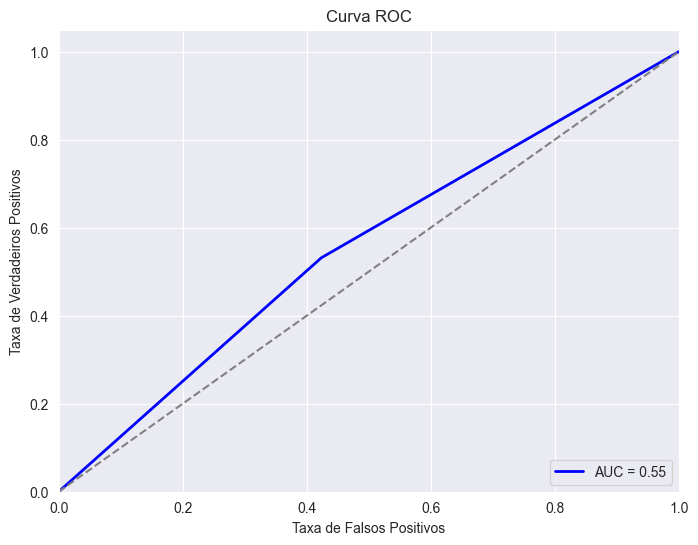

In [75]:

print("\n=== Curva ROC - Árvore de Decisão ===")
plot_roc_curve(fpr_dt, tpr_dt, auc_dt)

Aqui verificamos que a AUC está bem próximo de 0.5 ou seja a árvore de decisão está basicamente chutando.
O modelo não está muito melhor que o acaso. 


=== Curva ROC - MLP ===


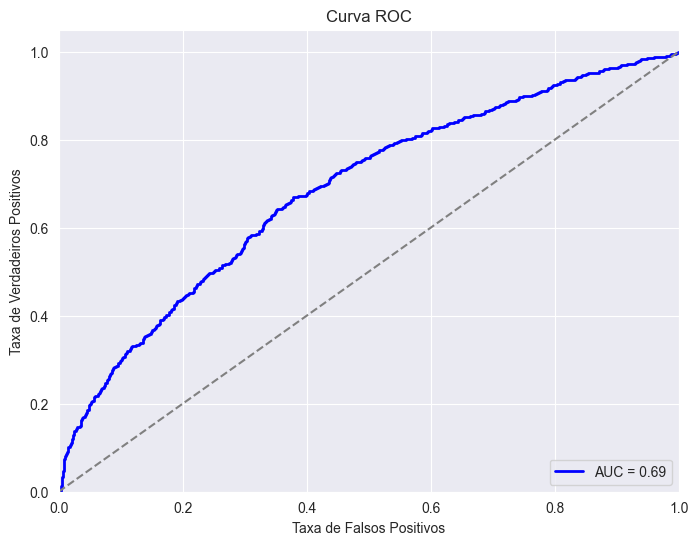

In [76]:
print("\n=== Curva ROC - MLP ===")
plot_roc_curve(fpr_mlp, tpr_mlp, auc_mlp)


Aqui verificamos que o valor da AUC é de 0,69 ou seja ele é bem melhor do que o acaso 

Exibindo os F1-scores

In [77]:

print(f"\nF1-Score Árvore de Decisão: {f1_dt:.4f}")
print(f"F1-Score MLP: {f1_mlp:.4f}")

# Comparando os resultados
if f1_dt > f1_mlp:
    print("\nA Árvore de Decisão tem o melhor F1-Score.")
else:
    print("\nO MLP tem o melhor F1-Score.")

if auc_dt > auc_mlp:
    print("\nA Árvore de Decisão tem a melhor AUC.")
else:
    print("\nO MLP tem a melhor AUC.")


F1-Score Árvore de Decisão: 0.5566
F1-Score MLP: 0.6296

O MLP tem o melhor F1-Score.

O MLP tem a melhor AUC.


### 1.3.1 Comparação dos desempenhos dos algoritmos

Nesta análise vamos comparar o desempenho usando os Algoritmos de Árvore de decisão e MLP. Utilizou-se 3 métricas: F1 Score,
Curva ROC e Matriz de confusão.
Em relação ao F1-Score, que avalia o equilíbrio entre precisão e revocação, os resultados obtidos foram: 
- Árvore de Decisão: F1 Score de 0,5566
- MLP: F1 score de 0,6296


O MLP apresentou um F1-Score Superior indicando que há uma maior capacidade de acertar classificações positivas sem comprometer a precisão geral

Quanto a análise da curva ROC observou-se que:
- A Árvore de decisão obteve um valor de AUC de 0,55 indicando apenas uma pouca melhora que o acaso
- O MLP alcançou um AUC de 0,69 evidenciando uma melhoria na capacidade de distinção entre classes positivas e classes negativas

Analisando a matriz de confusão, também percebe-se que essas conclusões são reforçadas
Observamos que:
-  A matriz de confusão da árvore de decisão apresentou uma quantidade elevada de falsos positivos e falsos negativos, o que comprometeu tanto a revocação quanto a precisão do modelo
-  Por outro lado, a matriz de confusão MLP demonstro uma maior concentração de verdadeiros positivos e verdadeiros negativos, com redução de erros de classificação refletiu-se então em um desempenho mais consistente

Portanto, considerando o conjunto de métricas analisadas, o MLP demonstrou desempenho superior ao modelo de Árvore de decisão, apresentando melhor capacidade preditiva, melhor separação entre as classes e um balanço mais eficiente entre precisão e revocação. 

### 2.0 Analise de Agrupamento

Com base nos dados que conseguimos nas seções anteriores o próximo passo é fazer uma análise de agrupamento, clustering, para identificar padrões sem supervisão 

### 2.1 Algoritmos K-Means e Hierárquico

Vamos trabalhar com dados já normalizados, por isso definimos X_clustering como sendo nossa variavel X_scaled.
Como K-means e Hierarquico são sensívels à escala das variáveis, temos que usar dessa maneira 

In [78]:
X_clustering = X_scaled
X_clustering

array([[ 0.49285724, -0.20220057, -0.60266027, ..., -0.24894554,
         0.85040593, -0.62984639],
       [-1.97387377, -0.89544039, -1.12566717, ...,  3.14123422,
         3.39834177,  0.20425061],
       [ 0.8782944 ,  1.3905267 ,  0.12576008, ..., -0.70247872,
        -0.49351159,  0.45132306],
       ...,
       [ 0.13374665,  1.2134082 ,  1.40930262, ...,  0.04599727,
        -0.27862903, -0.01622664],
       [-0.32975574, -0.97998184, -0.64606181, ..., -0.13904155,
         0.03403467, -0.48240778],
       [ 0.02216209,  0.49355038,  1.89211235, ..., -0.51933429,
        -0.44084439, -0.05439526]], shape=(2018, 93))

In [80]:
k_means = KMeans(n_clusters=2, random_state=42)
kmeans_labels = k_means.fit_predict(X_clustering)

Agora escolhemos 2 clusters com o objetivo de explorar a estrutura binária subjacente nos dados, mesmo
 que os rótulos não estejam disponiveis, fixamos random_state=42 para garantir a reprodutibilidade dos 
 dados. 

In [81]:
hierarchical = AgglomerativeClustering(n_clusters=2)
hierarchical_labels = hierarchical.fit_predict(X_clustering)

O Algoritmo hierarquico é baseado em distâncias, e, assim como o K-Means, usamos 2 clusters para manter a coerência comparativa

In [82]:
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_clustering)

Como o conjunto de dados original tem alta dimensionalidade, aqui vamos usar apenas 2 componentes 
para visualizar melhor os agrupamentos em um gráfico 2D

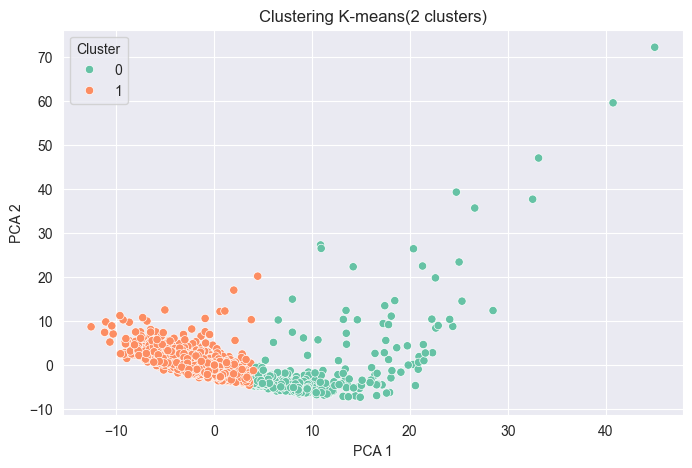

In [83]:
# Visualizando os clusters gerados pelo K-Means

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:,1], hue=kmeans_labels, palette='Set2')
plt.title("Clustering K-means(2 clusters)")
plt.xlabel("PCA 1")
plt.ylabel('PCA 2')
plt.legend(title="Cluster")
plt.show()

O scatter plot mostra como o algoritmo separou os dados após a redução para 2 dimensões, colorindo os clusters encontrados
pelo K-Means

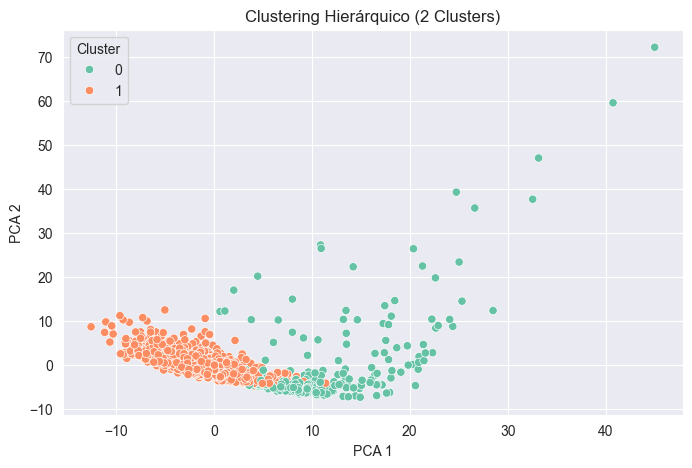

In [84]:
# Visualizando os clusters gerados pelo Hierárquico
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:,1], hue=hierarchical_labels, palette='Set2')
plt.title("Clustering Hierárquico (2 Clusters)")
plt.xlabel("PCA 1")
plt.ylabel('PCA 2')
plt.legend(title="Cluster")
plt.show()

Fazemos agora uma segunda visualização, dessa vez para o agrupamento hierárquico, para comparar se os clusters ficaram
mais separados os misturados. 

In [85]:
silhouette_kmeans = silhouette_score(X_clustering, kmeans_labels)
silhouette_hierarchical = silhouette_score(X_clustering, hierarchical_labels)

print(f"Silhouette Score - K-Means: {silhouette_kmeans:.4f}")
print(f"Silhouette Score - Hierárquico: {silhouette_hierarchical:.4f}")

Silhouette Score - K-Means: 0.4332
Silhouette Score - Hierárquico: 0.4533


Agora vamos avaliar a qualidade do modelo usando o Silhouette Score, pois é uma métrica que avalia
 a qualidade dos agrupamentos e é independente de rotulo. Assim vamos medir o quão bem as instâncias estão agrupadas.
Variando de -1 até 1.
Valores próximos de 1 indicam que os objetos estão bem agrupados e separados de outros clusters 
Valores próximos de 0 indicam que os objetos estão muito próximos na fronteira entre clusters.
Valores negativos indicam agrupamentos incorretos. 
O valor obtido para ambos os métodos está na faixa moderada, entre 0.4 e 0.5,  indicando que os agrupamentos não são perfeitamente bem
definidos, mas ainda assim apresentam uma separação razoável entre clusters. 

Comparativamente o hierárquico apresentou um desempenho superior em relação ao K-Means(hierárquico com um valor de 0.4533 e k-means com um 
valor de 0.4332) sugerindo que para esse conjunto de dados a abordagem 
hierárquica conseguiu formar agrupamentos um poucos mais coesos internamente e mais separados entre si do que o método k-means. 


### 2.2 Método do cotovelo

Vamos utilizar o método do cotovelo para determinar o número ideal de clusters para o K-means.
Basicamente o que iremos fazer é calcular a soma dos erros quadraticos internos para diferentes valores de k e observar
o ponto onde ocorre uma diminuição mais abrupta na curva, sugerindo um número ótimo de agrupamentos. 

In [86]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

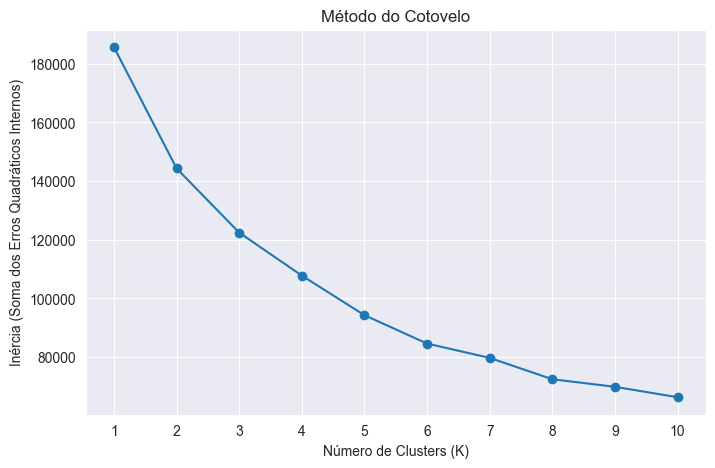

In [87]:
inertia = [] #Vamos criar uma lista inertia para armazenar os valores de inercia para cada K
K_values = range(1, 11) # Temos um range que vai de 1 até 10, serão testados como numero de clusters

for k in K_values: #Para cada valor de K o seguinte acontece:
    kmeans = KMeans(n_clusters=k, random_state=42) # Cria-se um modelo K-means
    # com o k respectivo e mantem random_state como 42 para garantir a reprodutibilidade dos dados
    kmeans.fit(X_clustering) #Aplica o algoritmo do kmeans aos dados normalizados
    #O algoritmo divide os dados em k grupos minimizando a inercia interna
    inertia.append(kmeans.inertia_)  #armazena a inercia

#Mostra o grafico do método do cotovelo
plt.figure(figsize=(8,5))
plt.plot(K_values, inertia, marker="o")
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos Erros Quadráticos Internos)')
plt.xticks(K_values)
plt.grid(True)
plt.show()

Com base no gráfico acima, pelo fato da redução da inércia ter sido maior entre k=2 e k=3, e também por que a redução torna-se menos expressiva 
após esse valor, conseguimos determinar que o melhor valor para K é 3. 

### 2.3 Comparando resultados entre K-Means e hierárquico com o valor de k obtido

Vamos rodar novamente os algoritmos com k=3

In [88]:
# K-Means com K=3
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_labels_final = kmeans_final.fit_predict(X_clustering)

# Hierárquico com K=3
hierarchical_final = AgglomerativeClustering(n_clusters=3)
hierarchical_labels_final = hierarchical_final.fit_predict(X_clustering)

In [89]:
# Avaliando a qualidade dos agrupamentos
silhouette_kmeans_final = silhouette_score(X_clustering, kmeans_labels_final)
silhouette_hierarchical_final = silhouette_score(X_clustering, hierarchical_labels_final)

print(f"Silhouette Score (K-Means): {silhouette_kmeans_final:.4f}")
print(f"Silhouette Score (Hierárquico): {silhouette_hierarchical_final:.4f}")

Silhouette Score (K-Means): 0.3974
Silhouette Score (Hierárquico): 0.4356


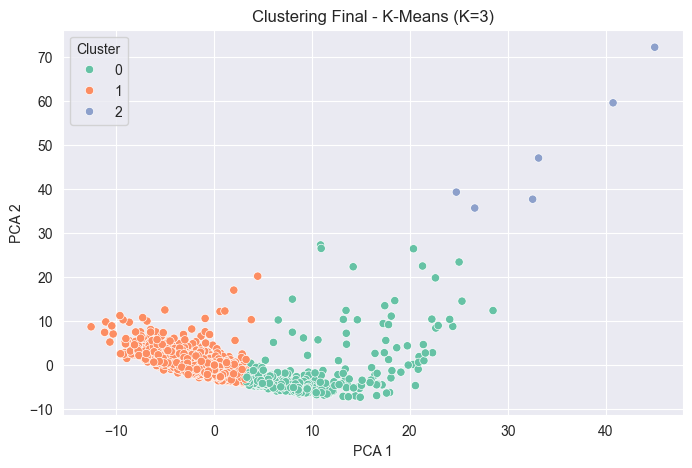

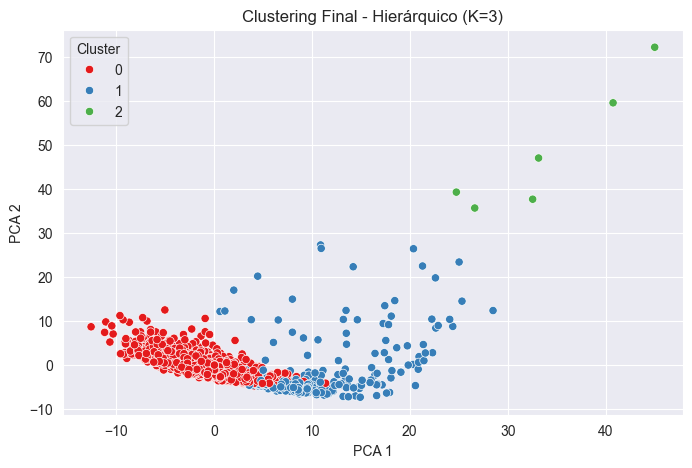

In [90]:
pca = PCA(n_components=2)
X_pca_final = pca.fit_transform(X_clustering)

# Plot K-Means
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=kmeans_labels_final, palette='Set2')
plt.title('Clustering Final - K-Means (K=3)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

# Plot Hierárquico
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=hierarchical_labels_final, palette='Set1')
plt.title('Clustering Final - Hierárquico (K=3)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

Ao aplicarmos os algoritmos K-Means e Hierárquico com K=3, definido a partir do método do cotovelo, 
avaliamos a qualidade dos agrupamentos por meio do Silhouette Score. O K-Means obteve um Silhouette 
Score de 0.3974, enquanto o método Hierárquico alcançou um valor superior de 0.4356. Ambos os resultados 
indicam que os agrupamentos possuem coesão interna moderada e separação razoável entre os clusters, mas 
o desempenho do algoritmo Hierárquico se destaca, sugerindo que ele conseguiu formar grupos mais bem 
definidos e com menor sobreposição entre si. Portanto, considerando apenas essa métrica, o algoritmo de 
agrupamento Hierárquico demonstrou uma melhor estruturação dos dados, sendo mais eficaz em capturar 
padrões naturais de separação no espaço multidimensional analisado.

### 2.4 Usando dois métodos diferentes de Linkage no algoritmo hierárquico

No agrupamento hierárquico, o linkage é definido como a distância entre os clusters e pode ser calculada de várias formas.
Entre elas temos duas:
- average: Usa a média das distâncias entre todos os pontos de dois clusters
- complete: Usa a maior distância possivel entre pontos de diferentes clusters 

Nos próximos códigos vamos testar o algoritmo hierárquico usando esses dois métodos de linkage


In [47]:
# Hierárquico com linkage = 'complete'
hierarchical_complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_complete = hierarchical_complete.fit_predict(X_clustering)
silhouette_complete = silhouette_score(X_clustering, labels_complete)

# Hierárquico com linkage = 'average'
hierarchical_average = AgglomerativeClustering(n_clusters=3, linkage='average')
labels_average = hierarchical_average.fit_predict(X_clustering)
silhouette_average = silhouette_score(X_clustering, labels_average)

# Exibindo os resultados
print(f"Silhouette Score (linkage='complete'): {silhouette_complete:.4f}")
print(f"Silhouette Score (linkage='average'): {silhouette_average:.4f}")


Silhouette Score (linkage='complete'): 0.7993
Silhouette Score (linkage='average'): 0.7668


Vamos agora fazer a visualização de ambos os métodos hierárquicos usando diferentes formas de linkage:

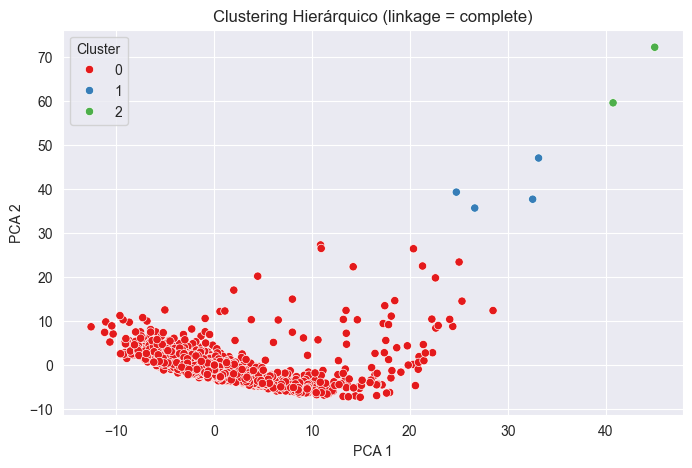

In [92]:
pca = PCA(n_components=2) #Usanmos n_components=2 para facilitar a visualização dos dados
X_pca_linkage = pca.fit_transform(X_clustering)

# Visualizando Clustering Complete
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_linkage[:, 0], y=X_pca_linkage[:, 1], hue=labels_complete, palette='Set1')
plt.title('Clustering Hierárquico (linkage = complete)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

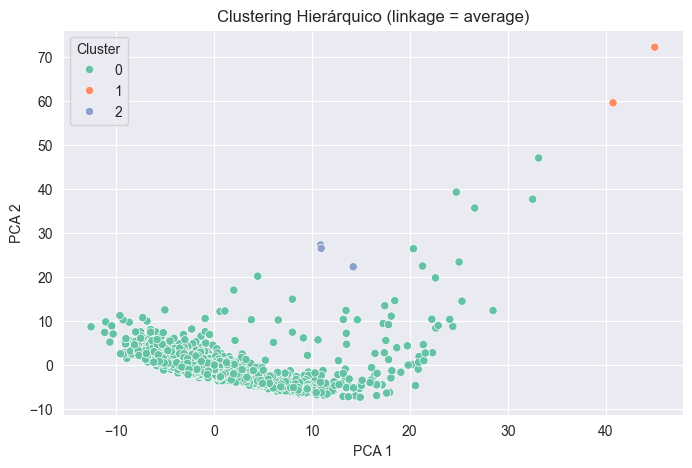

In [93]:
# Visualizando Clustering Average
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca_linkage[:, 0], y=X_pca_linkage[:, 1], hue=labels_average, palette='Set2')
plt.title('Clustering Hierárquico (linkage = average)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

Ao comparar dois métodos de linkage no algoritmo de agrupamento hierárquico com o número de clusters 
fixado em K=3, observamos que o linkage do tipo 'complete' obteve um Silhouette Score de 0.7993, 
enquanto o linkage 'average' atingiu um valor ligeiramente inferior, de 0.7668. Ambos os resultados 
indicam que os agrupamentos formados são bem definidos, com alta coesão interna e boa separação entre os 
clusters, mas o desempenho superior do linkage 'complete' sugere que este método foi mais eficaz em 
formar grupos mais compactos e com maior distinção entre si. Esse resultado é consistente com a natureza 
do linkage 'complete', que considera a maior distância entre pares de pontos ao unir clusters, 
favorecendo a formação de grupos mais separados e homogêneos. Portanto, com base na métrica de 
Silhouette Score, o linkage 'complete' demonstrou ser a estratégia mais adequada para o agrupamento 
hierárquico neste conjunto de dados.

### 3.5 Comparando resultados das técnicas de clustering usando métricas adequadas

Vamos comparar os resultados das diferentes técnicas de clustering aplicadas ao conjunto de dados usando como métrica inicial o
Silhouette Score. Essa métrica foi escolhida por ser mais apropriada em cenários de aprendizado não supervisionado, uma vez que avalia a coesão intra-cluster e a separação inter-cluster sem a necessidade de rótulos conhecidos.

O silhouette score obtido para o algoritmo k-means, considerando um k de 3, foi de 0.3974, indicando uma formação de clusters moderada, com
alguma sobreposição de grupos

O clustering hierárquico teve desempenho de 0.4356 (usando como linkage default o 'ward') indicando um desempenho razoável, com tendência positiva, mas não perfeito.

Quando outros métodos de linkage foram testados no clustering hierárquico com K=3, observou-se que o 
linkage 'complete' apresentou um Silhouette Score de 0.7993, indicando que os agrupamentos formados são 
bem coesos e razoavelmente separados, com boa estruturação geral. Já o linkage 'average' obteve um 
Silhouette Score de 0.7668, também refletindo agrupamentos consistentes, mas com leve redução na coesão 
interna e separação entre os clusters em comparação ao linkage 'complete'. Ambos os métodos mostraram 
desempenho superior ao linkage padrão 'ward', reforçando que a escolha do critério de união entre os 
clusters pode ter impacto direto na qualidade final do agrupamento. Dessa forma, o linkage 'complete' 
demonstrou ser o mais eficaz entre os testados, formando clusters mais bem definidos segundo a métrica 
de Silhouette Score.

A utilização do silhouette score é justificada pela natureza do problema: como clustering é não supervisionado não há rótulos verdadeiros para comparação direta. 
O Silhouette score fornece uma medida objetiva de qualidade dos agrupamentos com base apenas nas distâncias internas e externas aos clusters.


Agora vamos utilizar outras 2 métricas para clustering sem supervisão:
- Calinski-Harabasz Index (CHI): Mede a razão entre dispersão intra-cluster e inter-cluster (quanto maior, melhor).

- Davies-Bouldin Index (DBI): Mede a média das similaridades entre clusters (quanto menor, melhor).

In [53]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, name="Algoritmo"):
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    print(f"Resultados para {name}:")
    print(f" - Calinski-Harabasz Index: {calinski:.4f}")
    print(f" - Davies-Bouldin Index: {davies:.4f}")
    print()

evaluate_clustering(X_clustering, kmeans_labels_final, name="K-Means (k=3)")
evaluate_clustering(X_clustering, hierarchical_labels_final, name="Hierárquico (ward)")
evaluate_clustering(X_clustering, labels_complete, name="Hierárquico (complete)")
evaluate_clustering(X_clustering, labels_average, name="Hierárquico (average)")

Resultados para K-Means (k=3):
 - Calinski-Harabasz Index: 520.1378
 - Davies-Bouldin Index: 1.0642

Resultados para Hierárquico (ward):
 - Calinski-Harabasz Index: 480.5911
 - Davies-Bouldin Index: 1.0803

Resultados para Hierárquico (complete):
 - Calinski-Harabasz Index: 169.4225
 - Davies-Bouldin Index: 0.4870

Resultados para Hierárquico (average):
 - Calinski-Harabasz Index: 133.4977
 - Davies-Bouldin Index: 0.3815



Analisando os resultados para o Calinski-Harabasz Index (CHI), observamos que o K-Means (K=3) apresentou 
o maior valor, 520.1378, indicando que os clusters formados possuem boa separação entre si em relação à 
dispersão interna — o que sugere uma estrutura bem definida. O método Hierárquico com linkage 'ward' 
também apresentou um CHI relativamente alto (480.5911), reforçando sua capacidade de produzir 
agrupamentos razoavelmente bem separados. Em contrapartida, os métodos hierárquicos com linkage 
'complete' (169.4225) e 'average' (133.4977) apresentaram valores significativamente mais baixos de CHI, 
o que indica que os clusters nesses casos são menos dispersos entre si, possivelmente mais próximos ou 
concentrados no espaço de atributos.

Já ao analisar o Davies-Bouldin Index (DBI), que mede a similaridade entre os clusters (quanto menor, 
melhor), percebemos um comportamento inverso: o linkage 'average' apresentou o menor valor (0.3815), 
seguido do 'complete' com 0.4870, o que indica que esses métodos formaram clusters mais compactos e bem 
separados — ideal para tarefas de agrupamento. Por outro lado, tanto o K-Means (1.0642) quanto o 
Hierárquico com linkage 'ward' (1.0803) apresentaram DBIs mais altos, sugerindo maior sobreposição entre 
os clusters gerados.

Essas métricas foram escolhidas pois fornecem uma avaliação independente da necessidade de rótulos:
- O CHI mede a separação global dos agrupamentos com base na relação entre a variância entre clusters e a variância dentro dos clusters
- O DBI mede a compacidade dos clusters, penalizando agrupamentos com sobreposição errada.
Tais métricas complementam-se e fornecem uma visão ampla sobre a qualidade dos agrupamentos.


Portanto, enquanto o K-Means e o método ward obtiveram melhor desempenho, segundo o CHI (focando na 
separação entre grupos), os linkages 'average' e 'complete' demonstraram superioridade quando 
consideramos a compacidade e separação relativa dos agrupamentos, conforme refletido pelos baixos 
valores de DBI. Isso reforça a importância de usar múltiplas métricas para avaliar clustering, pois 
diferentes critérios podem revelar diferentes aspectos da qualidade dos agrupamentos.